=== İLK 5 SATIR ===
   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          No              No  Month-to-month   
1           

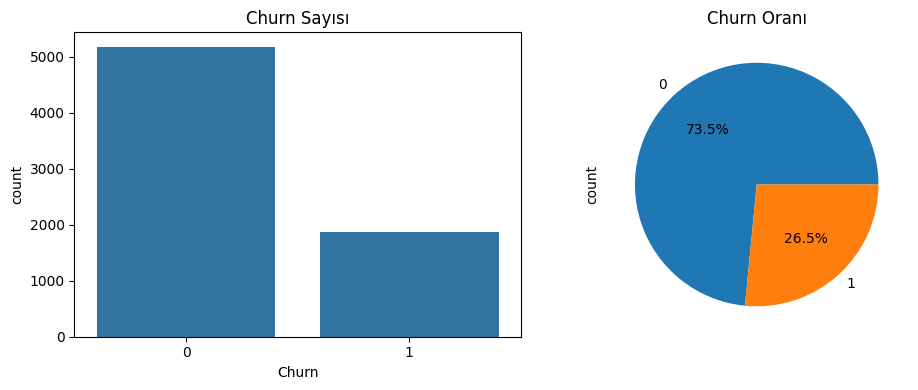


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409


=== XGBoost ===
              precision    recall  f1-score   support

           0       0.87      0.79      0.83      1035
           1       0.54      0.69      0.60       374

    accuracy                           0.76      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.76      0.77      1409

Modeller ./ dizinine kaydedildi.


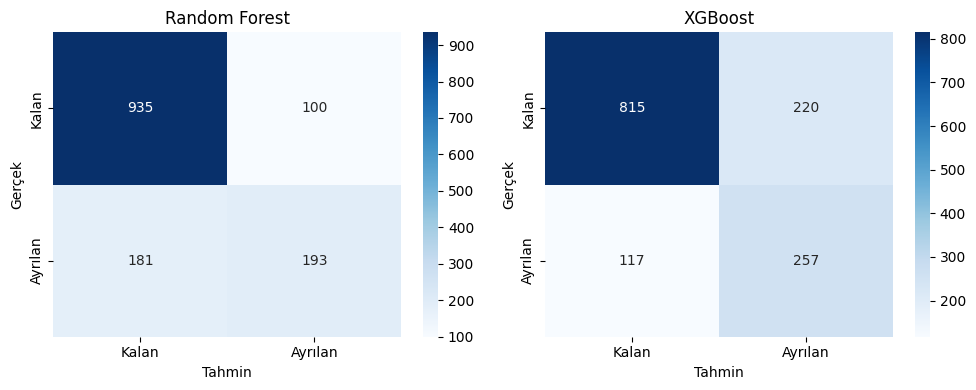

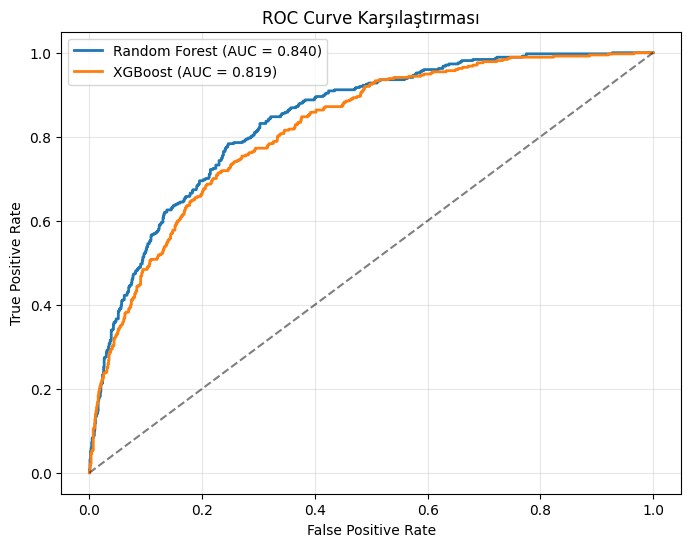

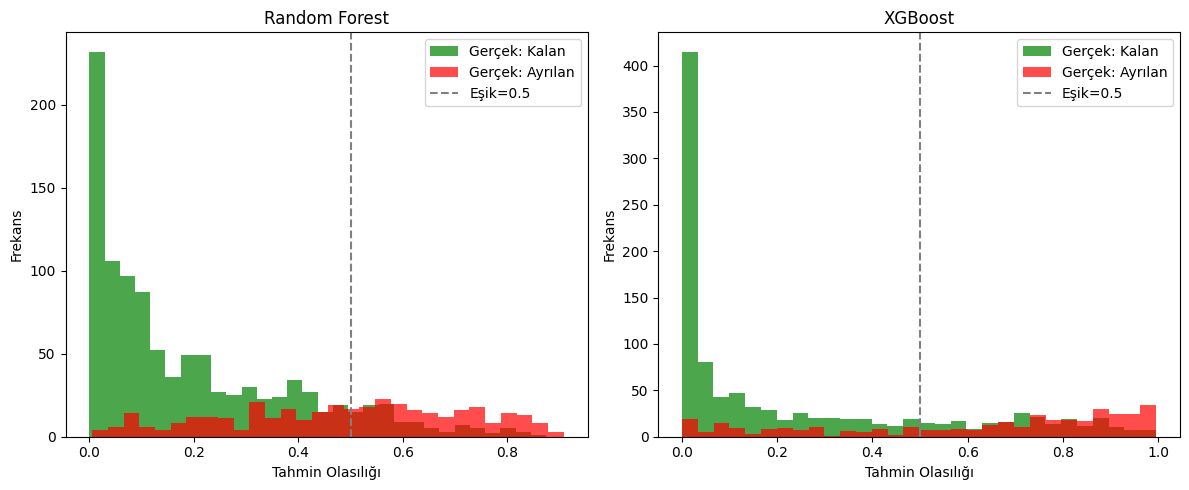

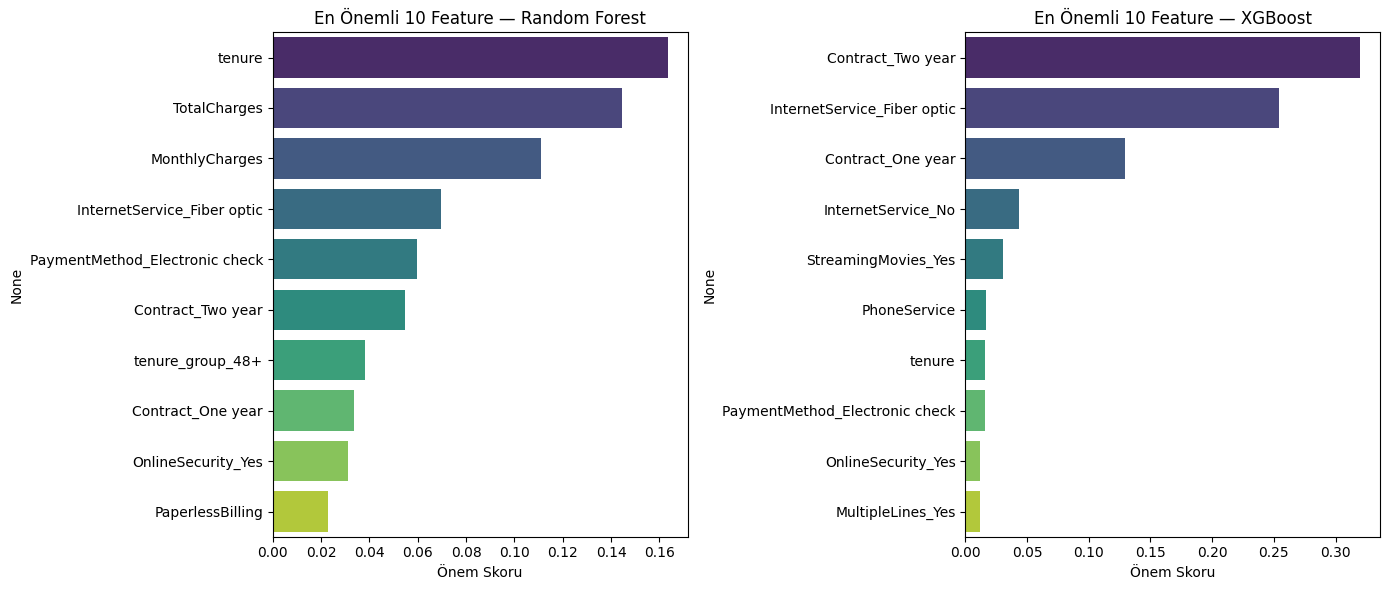


         🏆 MODEL PERFORMANS RAPORU
        Model  Accuracy  Precision  Recall  F1-Score
Random Forest    0.8006     0.6587  0.5160    0.5787
      XGBoost    0.7608     0.5388  0.6872    0.6040


In [ ]:
# ======================== SINIF 1 ========================
class DataLoader:
    """
    Görevi: Veriyi okuma, temizleme, ön inceleme
    """
    def __init__(self, file_path): ...
    def load_data(self) -> pd.DataFrame: ...
    def clean_data(self) -> None: ...
        # - TotalCharges sayısala çevir, NaN doldur
        # - Churn'ü 0/1 yap
        # - customerID'yi drop
    def eda_summary(self) -> None: ...
        # info(), describe(), eksik değer, churn dağılımı
    def get_clean_data(self) -> pd.DataFrame: ...

# ======================== SINIF 2 ========================
class ModelTrainer:
    """
    Görevi: Feature engineering, encoding, scaling, model eğitimi
    """
    def __init__(self, df: pd.DataFrame): ...
    def feature_engineering(self) -> None: ...
        # tenure_group oluştur
    def encode_features(self) -> None: ...
        # LabelEncoder + OneHotEncoder
    def scale_features(self) -> None: ...
        # StandardScaler
    def split_data(self, test_size=0.2) -> None: ...
    def train_models(self) -> None: ...
        # RandomForest + XGBoost eğit
    def evaluate_models(self) -> dict: ...
        # Accuracy, Precision, Recall, F1 döndür
    def save_models(self, path=".") -> None: ...

# ======================== SINIF 3 ========================
class Visualizer:
    """
    Görevi: Görselleştirme, raporlama, çıktılar
    """
    def __init__(self, model_trainer: ModelTrainer): ...
    def plot_feature_importance(self) -> None: ...
    def plot_roc_curve(self) -> None: ...
    def plot_confusion_matrices(self) -> None: ...
    def plot_probability_distribution(self) -> None: ...
    def plot_shap_summary(self) -> None: ...  # bonus
    def create_report(self) -> pd.DataFrame: ...

# ======================== KULLANIM ========================
# 1. VERİ
loader = DataLoader("WA_Fn-UseC_-Telco-Customer-Churn.csv")
loader.load_data()
loader.clean_data()
loader.eda_summary()
df = loader.get_clean_data()

# 2. MODEL
trainer = ModelTrainer(df)
trainer.feature_engineering()
trainer.encode_features()
trainer.scale_features()
trainer.split_data()
trainer.train_models()
metrics = trainer.evaluate_models()
trainer.save_models()

# 3. GÖRSELLEŞTİRME
viz = Visualizer(trainer)
viz.plot_feature_importance()
viz.plot_roc_curve()
viz.plot_confusion_matrices()
viz.plot_probability_distribution()
viz.create_report()

# ============================================================
# KÜTÜPHANELER
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc,
                             classification_report)


# ============================================================
# SINIF 1 — VERİ OKUMA VE TEMİZLİK
# ============================================================
class DataLoader:
    """
    Veriyi okur, temizler ve ön inceleme yapar.
    """
    def __init__(self, file_path: str):
        self.file_path = file_path
        self.df = None

    def load_data(self) -> pd.DataFrame:
        df = pd.read_csv(self.file_path)
        self.df = df
        return df

    def clean_data(self):
        df = self.df

        # TotalCharges sayısala çevir
        df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
        df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

        # Hedef değişkeni binary yap
        df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

        # Gereksiz sütun
        df.drop("customerID", axis=1, inplace=True)

        self.df = df

    def eda_summary(self):
        df = self.df
        print("=== İLK 5 SATIR ===")
        print(df.head(), "\n")
        print("=== VERİ YAPISI ===")
        print(df.info(), "\n")
        print("=== İSTATİSTİKLER ===")
        print(df.describe(), "\n")
        print("=== EKSİK DEĞER ===")
        print(df.isnull().sum(), "\n")
        print("=== CHURN DAĞILIMI ===")
        print(df["Churn"].value_counts(normalize=True))

        fig, ax = plt.subplots(1, 2, figsize=(10, 4))
        sns.countplot(x="Churn", data=df, ax=ax[0])
        ax[0].set_title("Churn Sayısı")
        df["Churn"].value_counts().plot(kind="pie", autopct="%1.1f%%", ax=ax[1])
        ax[1].set_title("Churn Oranı")
        plt.tight_layout()
        plt.show()

    def get_clean_data(self) -> pd.DataFrame:
        return self.df


# ============================================================
# SINIF 2 — MODELE HAZIRLIK VE EĞİTİM
# ============================================================
class ModelTrainer:
    """
    Feature engineering, encoding, scaling, model eğitimi.
    """
    def __init__(self, df: pd.DataFrame):
        self.df = df.copy()
        self.X = None
        self.y = None
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.scaler = StandardScaler()
        self.rf_model = None
        self.xgb_model = None
        self.metrics = {}

    def feature_engineering(self):
        df = self.df
        df["tenure_group"] = pd.cut(
            df["tenure"],
            bins=[-1, 12, 24, 48, 72],
            labels=["0-12", "12-24", "24-48", "48+"]
        )
        self.df = df

    def encode_features(self):
        df = self.df

        binary_cols = ["gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]
        le = LabelEncoder()
        for col in binary_cols:
            df[col] = le.fit_transform(df[col])

        multi_cols = [
            "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
            "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
            "Contract", "PaymentMethod", "tenure_group"
        ]
        df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

        self.df = df

    def scale_features(self):
        num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
        self.X[num_cols] = self.scaler.fit_transform(self.X[num_cols])
        self.X_test[num_cols] = self.scaler.transform(self.X_test[num_cols])

    def split_data(self, test_size=0.2, random_state=42):
        self.X = self.df.drop("Churn", axis=1)
        self.y = self.df["Churn"]
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X, self.y, test_size=test_size, random_state=random_state, stratify=self.y
        )
        # Scaling fit_transform train'e uygulanır
        num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
        self.X_train[num_cols] = self.scaler.fit_transform(self.X_train[num_cols])
        self.X_test[num_cols] = self.scaler.transform(self.X_test[num_cols])

    def train_models(self):
        # Random Forest
        self.rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
        self.rf_model.fit(self.X_train, self.y_train)

        # XGBoost
        scale = (self.y_train == 0).sum() / (self.y_train == 1).sum()
        self.xgb_model = XGBClassifier(scale_pos_weight=scale, random_state=42)
        self.xgb_model.fit(self.X_train, self.y_train)

    def evaluate_models(self) -> dict:
        y_pred_rf = self.rf_model.predict(self.X_test)
        y_pred_xgb = self.xgb_model.predict(self.X_test)

        for name, y_pred in [("Random Forest", y_pred_rf), ("XGBoost", y_pred_xgb)]:
            self.metrics[name] = {
                "Accuracy": round(accuracy_score(self.y_test, y_pred), 4),
                "Precision": round(precision_score(self.y_test, y_pred), 4),
                "Recall": round(recall_score(self.y_test, y_pred), 4),
                "F1-Score": round(f1_score(self.y_test, y_pred), 4)
            }
            print(f"\n=== {name} ===")
            print(classification_report(self.y_test, y_pred))

        return self.metrics

    def save_models(self, path="."):
        joblib.dump(self.rf_model, f"{path}/rf_model.pkl")
        joblib.dump(self.xgb_model, f"{path}/xgb_model.pkl")
        joblib.dump(self.scaler, f"{path}/scaler.pkl")
        print(f"Modeller {path}/ dizinine kaydedildi.")

    def load_models(self, path="."):
        self.rf_model = joblib.load(f"{path}/rf_model.pkl")
        self.xgb_model = joblib.load(f"{path}/xgb_model.pkl")
        self.scaler = joblib.load(f"{path}/scaler.pkl")
        return self


# ============================================================
# SINIF 3 — ÇIKTILAR VE GÖRSELLEŞTİRME
# ============================================================
class Visualizer:
    """
    Görselleştirme, raporlama ve final çıktıları üretir.
    """
    def __init__(self, trainer: ModelTrainer):
        self.trainer = trainer
        self.y_pred_rf = trainer.rf_model.predict(trainer.X_test)
        self.y_pred_xgb = trainer.xgb_model.predict(trainer.X_test)
        self.y_prob_rf = trainer.rf_model.predict_proba(trainer.X_test)[:, 1]
        self.y_prob_xgb = trainer.xgb_model.predict_proba(trainer.X_test)[:, 1]

    def plot_feature_importance(self, top_n=10):
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        for ax, model, name in zip(axes, [self.trainer.rf_model, self.trainer.xgb_model],
                                   ["Random Forest", "XGBoost"]):
            importances = model.feature_importances_
            feat_imp = pd.Series(importances, index=self.trainer.X_test.columns)
            feat_imp = feat_imp.sort_values(ascending=False).head(top_n)

            sns.barplot(x=feat_imp.values, y=feat_imp.index, ax=ax, palette="viridis")
            ax.set_title(f"En Önemli {top_n} Feature — {name}")
            ax.set_xlabel("Önem Skoru")

        plt.tight_layout()
        plt.show()

    def plot_roc_curve(self):
        fpr_rf, tpr_rf, _ = roc_curve(self.trainer.y_test, self.y_prob_rf)
        fpr_xgb, tpr_xgb, _ = roc_curve(self.trainer.y_test, self.y_prob_xgb)
        auc_rf = auc(fpr_rf, tpr_rf)
        auc_xgb = auc(fpr_xgb, tpr_xgb)

        plt.figure(figsize=(8, 6))
        plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})", lw=2)
        plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.3f})", lw=2)
        plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve Karşılaştırması")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

    def plot_confusion_matrices(self):
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))

        for ax, y_pred, name in zip(axes, [self.y_pred_rf, self.y_pred_xgb],
                                    ["Random Forest", "XGBoost"]):
            cm = confusion_matrix(self.trainer.y_test, y_pred)
            sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                        xticklabels=["Kalan", "Ayrılan"],
                        yticklabels=["Kalan", "Ayrılan"])
            ax.set_title(name)
            ax.set_xlabel("Tahmin")
            ax.set_ylabel("Gerçek")

        plt.tight_layout()
        plt.show()

    def plot_probability_distribution(self):
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        for ax, probs, name in zip(axes, [self.y_prob_rf, self.y_prob_xgb],
                                   ["Random Forest", "XGBoost"]):
            ax.hist(probs[self.trainer.y_test == 0], bins=30, alpha=0.7,
                    label="Gerçek: Kalan", color="green")
            ax.hist(probs[self.trainer.y_test == 1], bins=30, alpha=0.7,
                    label="Gerçek: Ayrılan", color="red")
            ax.axvline(0.5, color="gray", ls="--", label="Eşik=0.5")
            ax.set_title(name)
            ax.set_xlabel("Tahmin Olasılığı")
            ax.set_ylabel("Frekans")
            ax.legend()

        plt.tight_layout()
        plt.show()

    def create_report(self) -> pd.DataFrame:
        results = {
            "Model": ["Random Forest", "XGBoost"],
            "Accuracy": [
                accuracy_score(self.trainer.y_test, self.y_pred_rf),
                accuracy_score(self.trainer.y_test, self.y_pred_xgb)
            ],
            "Precision": [
                precision_score(self.trainer.y_test, self.y_pred_rf),
                precision_score(self.trainer.y_test, self.y_pred_xgb)
            ],
            "Recall": [
                recall_score(self.trainer.y_test, self.y_pred_rf),
                recall_score(self.trainer.y_test, self.y_pred_xgb)
            ],
            "F1-Score": [
                f1_score(self.trainer.y_test, self.y_pred_rf),
                f1_score(self.trainer.y_test, self.y_pred_xgb)
            ]
        }
        df_report = pd.DataFrame(results).round(4)
        print("\n" + "=" * 55)
        print("         🏆 MODEL PERFORMANS RAPORU")
        print("=" * 55)
        print(df_report.to_string(index=False))
        print("=" * 55)
        return df_report

    def plot_shap_summary(self, max_display=10):
        try:
            import shap
            explainer = shap.TreeExplainer(self.trainer.xgb_model)
            shap_values = explainer.shap_values(self.trainer.X_test)
            shap.summary_plot(shap_values, self.trainer.X_test, max_display=max_display)
        except ImportError:
            print("SHAP kurulu değil. Kurmak için: !pip install shap")


# ============================================================
# KULLANIM
# ============================================================
if __name__ == "__main__":
    # ---- 1. VERİ HAZIRLAMA ----
    loader = DataLoader("WA_Fn-UseC_-Telco-Customer-Churn.csv")
    loader.load_data()
    loader.clean_data()
    loader.eda_summary()
    df = loader.get_clean_data()

    # ---- 2. MODEL EĞİTİMİ ----
    trainer = ModelTrainer(df)
    trainer.feature_engineering()
    trainer.encode_features()
    trainer.split_data()
    trainer.train_models()
    metrics = trainer.evaluate_models()
    trainer.save_models()

    # ---- 3. GÖRSELLEŞTİRME ----
    viz = Visualizer(trainer)
    viz.plot_confusion_matrices()
    viz.plot_roc_curve()
    viz.plot_probability_distribution()
    viz.plot_feature_importance()
    report = viz.create_report()